In [1]:
# Imports
import pandas as pd
from pathlib import Path
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

from utils.config import OUT_DIR, CLUBS_ORDERED
import importlib
import utils.graph.layout
importlib.reload(utils.graph.layout)
from utils.graph.layout import plot_graph_by_club


SRC_ROOT = Path('').resolve().parents[1]
PARQUET_OUT_DIR = SRC_ROOT / OUT_DIR

In [2]:
# Dataframes loading

df_proceedings = pd.read_parquet(PARQUET_OUT_DIR / 'proceedings.parquet')

# Using the new processed votings parquet file
df_votings = pd.read_parquet(PARQUET_OUT_DIR / 'votings_processed.parquet')

df_votes = pd.read_parquet(PARQUET_OUT_DIR / 'votes.parquet')
df_members = pd.read_parquet(PARQUET_OUT_DIR / 'members.parquet')

# Quick check of the new vote_weight column
display(df_votings[['sitting', 'votingNumber', 'vote_weight']].head())

,sitting,votingNumber,vote_weight
0,1,3,2.967367
1,1,4,4.557860
2,1,5,4.410480
3,1,6,4.457237
4,1,7,2.759279


In [3]:
# Merge vote_weight directly into the votes dataframe
votes_with_weights = df_votes[["sitting", "votingNumber", "MP", "vote"]].merge(
    df_votings[["sitting", "votingNumber", "vote_weight"]],
    on=["sitting", "votingNumber"],
    how="inner",
)
display(votes_with_weights.head())

,sitting,votingNumber,MP,vote,vote_weight
0,1,3,1,YES,2.967367
1,1,3,2,ABSTAIN,2.967367
2,1,3,4,YES,2.967367
3,1,3,5,YES,2.967367
4,1,3,6,YES,2.967367


In [4]:
# Generate pairs of MPs who participated in the same votings
pairs = votes_with_weights.merge(
    votes_with_weights,
    on=["sitting", "votingNumber"],
    suffixes=("_i", "_j"),
)

# Keep only distinct pairs
pairs = pairs[pairs["MP_i"] < pairs["MP_j"]].copy()

# Calculate score and denominator based directly on the new vote_weight
pairs["denom_w"] = pairs["vote_weight_i"]
pairs["score_w"] = pairs["denom_w"] * pairs["vote_i"].eq(pairs["vote_j"]).astype(float)

In [5]:
# Calculate weighted agreement score
edge_stats = pairs.groupby(["MP_i", "MP_j"], as_index=False).agg(
    score=("score_w", "sum"),
    denom=("denom_w", "sum"),
)

edge_stats = edge_stats[edge_stats["denom"] > 0].copy()
edge_stats["weight"] = edge_stats["score"] / edge_stats["denom"]

display(edge_stats.head())

,MP_i,MP_j,score,denom,weight
0,1,2,122.957619,8402.191544,0.014634
1,1,3,4480.326756,4560.601512,0.982398
2,1,4,8377.172271,8440.900481,0.992450
3,1,5,7804.092685,7907.910599,0.986872
4,1,6,6371.140983,7225.921029,0.881706


In [6]:
# Add members' clubs to the graph
members_nodes = df_members[["MP", "club"]].drop_duplicates(subset=["MP"]).copy()

G = nx.Graph()

# Add nodes
for row in members_nodes.itertuples(index=False):
    G.add_node(int(row.MP), club=row.club)

# Add edges with the calculated weights
for row in edge_stats.itertuples(index=False):
    G.add_edge(
        int(row.MP_i),
        int(row.MP_j),
        weight=float(row.weight)
    )

G.remove_node(166)

graph_stats = {
    "nodes": G.number_of_nodes(),
    "edges": G.number_of_edges(),
    "weight_min": float(edge_stats["weight"].min()) if not edge_stats.empty else None,
    "weight_mean": float(edge_stats["weight"].mean()) if not edge_stats.empty else None,
    "weight_max": float(edge_stats["weight"].max()) if not edge_stats.empty else None,
}

print(graph_stats)

{'nodes': 497, 'edges': 122194, 'weight_min': 0.0, 'weight_mean': 0.49194542602635105, 'weight_max': 1.0}


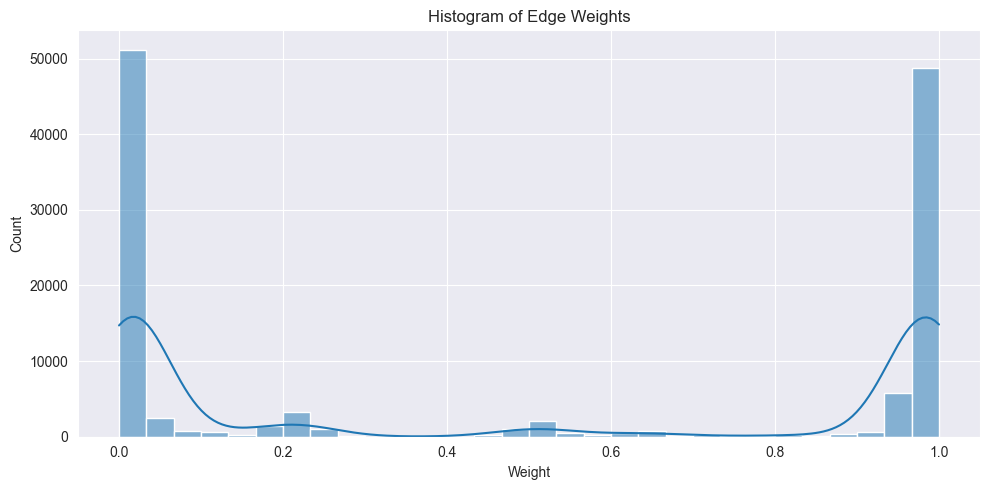

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(edge_stats["weight"], bins=30, kde=True)
plt.title("Histogram of Edge Weights")
plt.xlabel("Weight")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

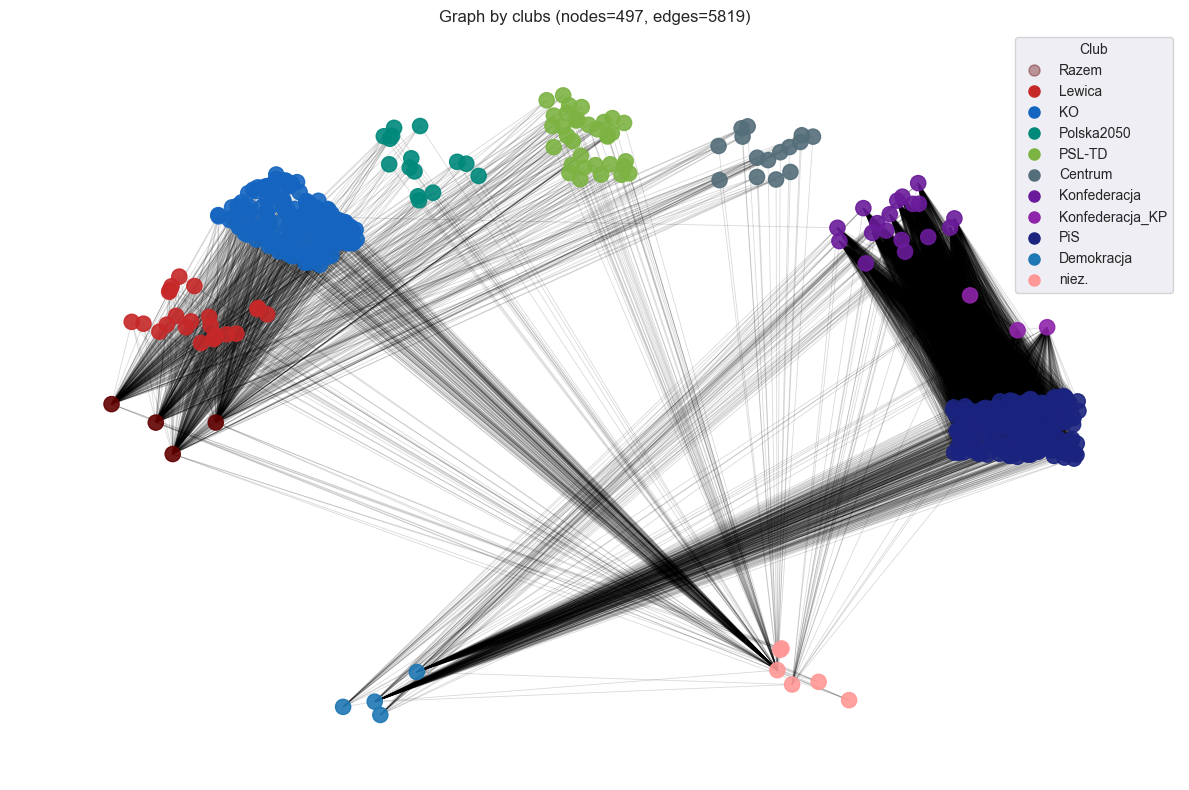

In [8]:
plot_graph_by_club(G, threshold_for_edges=(0.3, 0.8), clubs_ordered=CLUBS_ORDERED)

# Graph visualizations based on thresholds

First we filter the inner party edges and then plot two graphs: one with only the strongest cross-party edges (0.95-1.0) and another with the middle ones (0.4-0.6).

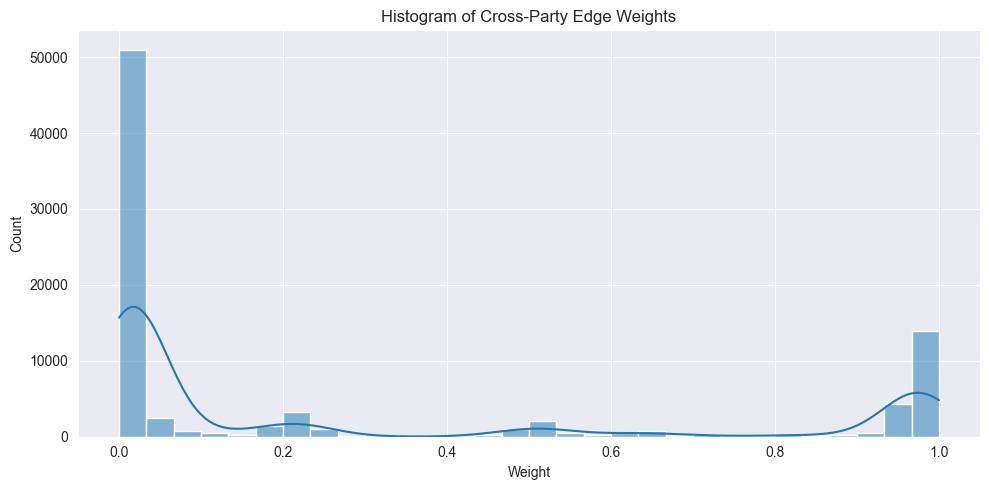

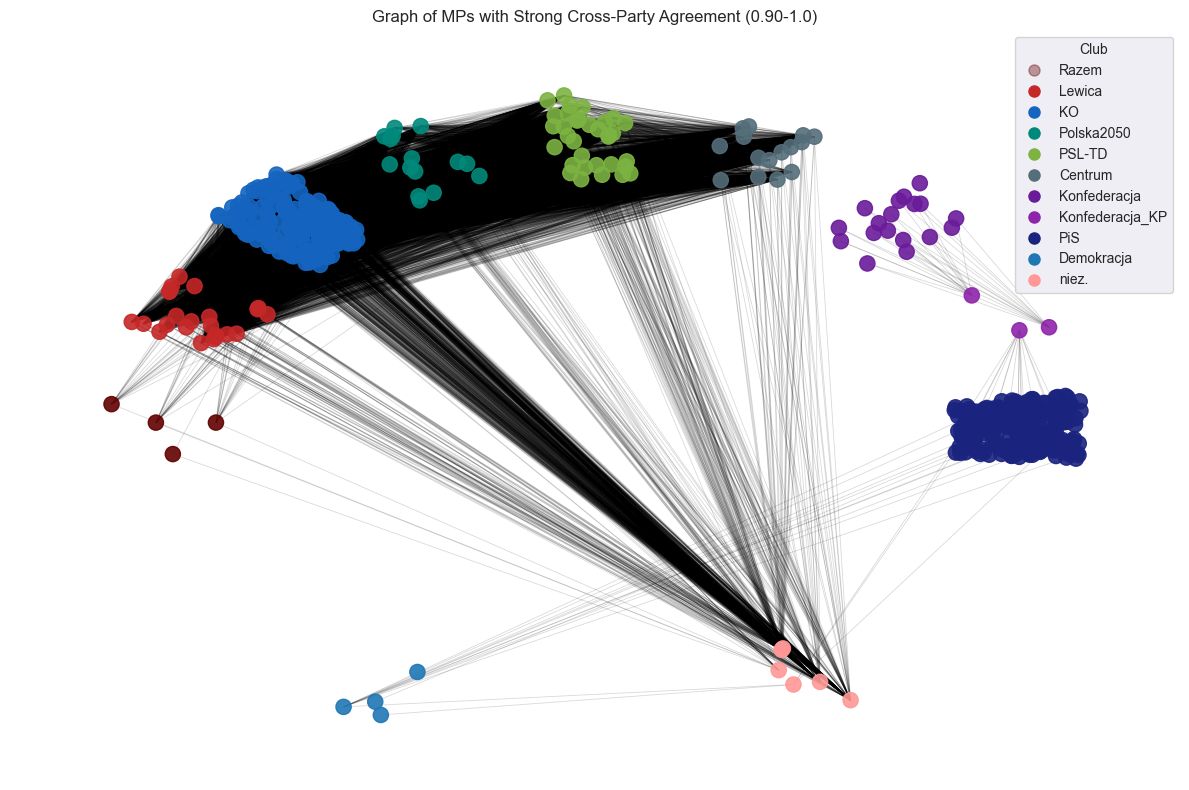

In [22]:
cross_party_edges = [
    (u, v, d) for u, v, d in G.edges(data=True)
    if G.nodes[u]['club'] != G.nodes[v]['club']
]

cross_party_G = nx.create_empty_copy(G)
cross_party_G.add_edges_from(cross_party_edges)

# Extract weights from cross-party edges
cross_party_weights = [d["weight"] for _, _, d in cross_party_edges]

plt.figure(figsize=(10, 5))
sns.histplot(cross_party_weights, bins=30, kde=True)
plt.title("Histogram of Cross-Party Edge Weights")
plt.xlabel("Weight")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


plot_graph_by_club(cross_party_G, threshold_for_edges=(0.9, 1.0), clubs_ordered=CLUBS_ORDERED, title="Graph of MPs with Strong Cross-Party Agreement (0.90-1.0)")

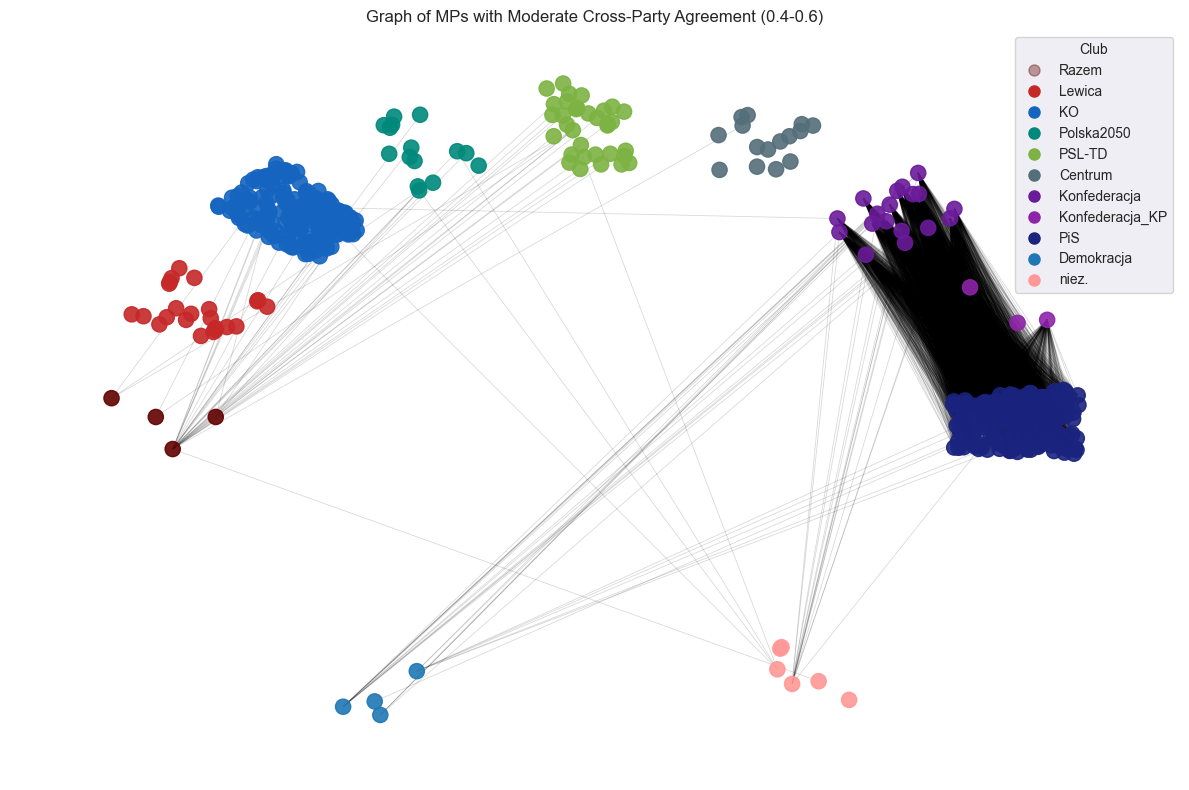

In [21]:
plot_graph_by_club(G, threshold_for_edges=(0.4, 0.6), clubs_ordered=CLUBS_ORDERED, title="Graph of MPs with Moderate Cross-Party Agreement (0.4-0.6)")

# A heatmap of all MPs

ordered by their clubs, showing the weight of their agreement (black/grey = never voted together, bright colors = often voted together). This is a more traditional way to visualize voting agreement and can help identify clusters of MPs who vote similarly.

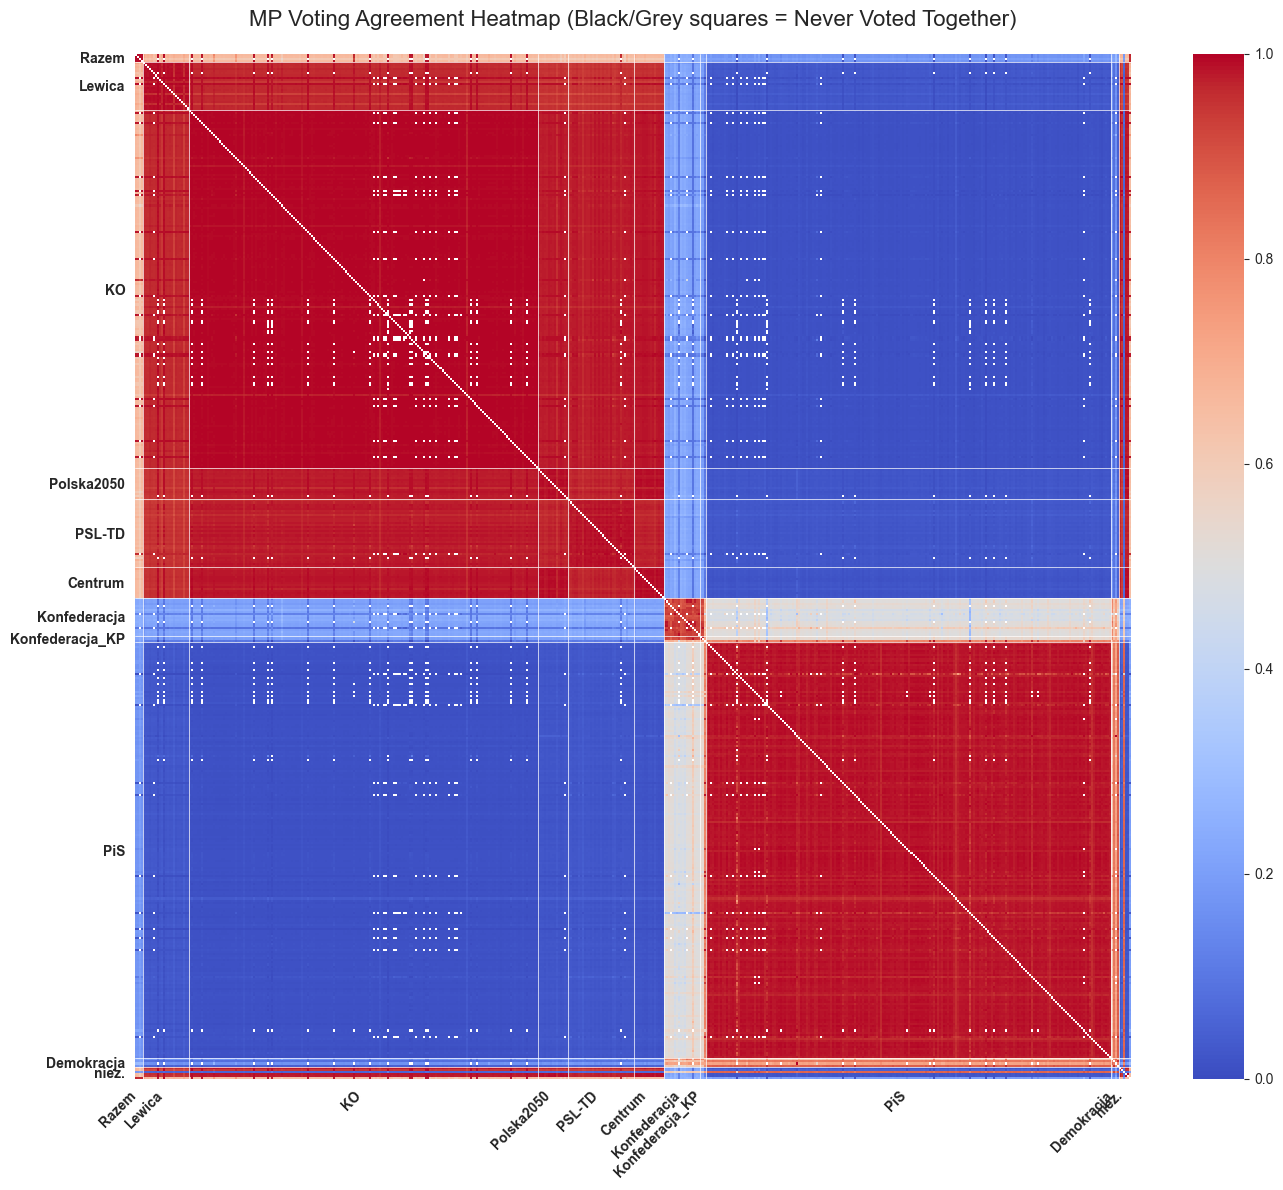

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

# --- NEW: Import your custom club order ---
try:
    from utils.config import CLUBS_ORDERED
except ImportError:
    CLUBS_ORDERED = []

# 1. Create an MP x MP matrix of weights
matrix = nx.to_pandas_adjacency(G, weight='weight', nonedge=np.nan)

# Extract nodes and their clubs
mp_clubs = pd.DataFrame([
    {"MP": n, "club": d["club"]} for n, d in G.nodes(data=True)
])

# --- NEW: Define the custom sorting order ---
# Keep only the ordered clubs that actually exist in the current graph
known_clubs = [c for c in CLUBS_ORDERED if c in mp_clubs["club"].values]
# Any clubs not in your order get sorted alphabetically at the end
unknown_clubs = sorted([c for c in mp_clubs["club"].unique() if c not in known_clubs])

final_order = known_clubs + unknown_clubs

# Convert the 'club' column to an ordered categorical type
mp_clubs["club"] = pd.Categorical(mp_clubs["club"], categories=final_order, ordered=True)

# Sort the MPs by this new categorical club order
mp_clubs = mp_clubs.sort_values("club")

# Reorder the matrix rows and columns to match
sorted_mps = mp_clubs["MP"].tolist()
matrix = matrix.loc[sorted_mps, sorted_mps]

# 2. Calculate the boundaries and centers for the club labels
club_counts = mp_clubs.groupby("club", sort=False).size()
# Drop clubs with 0 MPs (if any empty categories remain)
club_counts = club_counts[club_counts > 0]

boundaries = [0] + club_counts.cumsum().tolist()
tick_positions = [(boundaries[i] + boundaries[i+1]) / 2 for i in range(len(club_counts))]
club_names = club_counts.index.tolist()

# 3. Plot the heatmap
plt.figure(figsize=(14, 12))

ax = plt.axes()
ax.set_facecolor("white")

sns.heatmap(matrix, cmap="coolwarm", xticklabels=False, yticklabels=False, ax=ax)

# Draw thin white lines to visually separate the parties
for b in boundaries[1:-1]:
    ax.axhline(b, color='white', linewidth=0.5)
    ax.axvline(b, color='white', linewidth=0.5)

# Apply our custom center ticks and club names
ax.set_xticks(tick_positions)
ax.set_xticklabels(club_names, rotation=45, ha='right', fontsize=10, fontweight='bold')

ax.set_yticks(tick_positions)
ax.set_yticklabels(club_names, rotation=0, fontsize=10, fontweight='bold')

plt.title("MP Voting Agreement Heatmap (Black/Grey squares = Never Voted Together)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

def analyze_internal_party_cohesion(party_name, G, df_votes, df_members, top_n=10):
    """
    Finds the members with the lowest internal compatibility within a specific party.
    Also checks their overall voting participation to see if absence is the cause.
    """
    # 1. Get all MPs belonging to the target party
    party_mps = [n for n, d in G.nodes(data=True) if d.get('club') == party_name]

    if not party_mps:
        print(f"No MPs found for party: {party_name}")
        return

    rebel_stats = []

    # 2. Calculate average internal agreement for each MP
    for mp in party_mps:
        internal_weights = []

        # Look at all connections this MP has
        for neighbor in G.neighbors(mp):
            # Only consider connections to OTHER members of the SAME party
            if neighbor in party_mps:
                internal_weights.append(G[mp][neighbor]['weight'])

        if internal_weights:
            avg_weight = sum(internal_weights) / len(internal_weights)
            rebel_stats.append({
                "MP": mp,
                "avg_internal_compatibility": avg_weight,
                "internal_connections": len(internal_weights)
            })

    df_rebels = pd.DataFrame(rebel_stats)

    # 3. Calculate total voting participation for each MP
    # This helps us test your hypothesis about missing votings
    participation_counts = df_votes.groupby("MP").size().reset_index(name="total_votings_attended")
    df_rebels = df_rebels.merge(participation_counts, on="MP", how="left")

    # 4. Add names for readability
    mp_names = df_members[["MP", "firstName", "lastName"]].drop_duplicates()
    df_rebels = df_rebels.merge(mp_names, on="MP", how="left")

    # 5. Sort by the lowest compatibility
    df_rebels = df_rebels.sort_values("avg_internal_compatibility", ascending=True)

    # Reorder columns for a clean output
    df_rebels = df_rebels[[
        "firstName", "lastName", "avg_internal_compatibility",
        "total_votings_attended", "internal_connections"
    ]]

    print(f"--- Lowest Internal Compatibility in {party_name} ---")
    display(df_rebels.head(top_n))
    return df_rebels

# ==========================================
# Example Usage:
# Replace "PiS" or "KO" with the name of the party you saw the blue lines in.
# ==========================================

# First, let's find the median participation across ALL MPs as a baseline
median_votes = df_votes.groupby("MP").size().median()
print(f"Median votings attended by an average MP: {median_votes}\n")

# Now check the specific party
df_pis_rebels = analyze_internal_party_cohesion("PiS", G, df_votes, df_members, top_n=10)

Median votings attended by an average MP: 3612.0

--- Lowest Internal Compatibility in PiS ---


,firstName,lastName,avg_internal_compatibility,total_votings_attended,internal_connections
143,Artur,Soboń,0.942260,52,188
70,Mariusz,Kamiński,0.953621,117,189
25,Janusz,Cieszyński,0.955921,3233,201
101,Dariusz,Matecki,0.959485,2849,201
183,Bartłomiej,Wróblewski,0.963024,3006,201
130,Marcin,Romanowski,0.964154,663,198
63,Paweł,Jabłoński,0.964277,3255,201
87,Maria,Kurowska,0.967538,3697,201
150,Wojciech,Szarama,0.971423,3118,201
186,Zbigniew,Ziobro,0.971651,522,201


In [12]:
import pandas as pd

def analyze_blue_dots(party_name, edge_stats, df_members, top_n=15):
    """
    Finds the specific PAIRS of MPs within the same party that have the lowest agreement.
    This explains the isolated blue dots on the heatmap.
    """
    # 1. Create a dictionary for MP info to easily map names and clubs
    mp_info = df_members[["MP", "club", "firstName", "lastName"]].drop_duplicates()

    # 2. Add MP 1 information
    pairs = edge_stats.merge(
        mp_info, left_on="MP_i", right_on="MP", how="inner"
    ).rename(columns={"club": "club_1", "firstName": "firstName_1", "lastName": "lastName_1"})

    # 3. Add MP 2 information
    pairs = pairs.merge(
        mp_info, left_on="MP_j", right_on="MP", how="inner"
    ).rename(columns={"club": "club_2", "firstName": "firstName_2", "lastName": "lastName_2"})

    # 4. Filter for pairs where BOTH MPs belong to the specified party
    internal_pairs = pairs[(pairs["club_1"] == party_name) & (pairs["club_2"] == party_name)].copy()

    if internal_pairs.empty:
        print(f"No internal pairs found for party: {party_name}")
        return

    # 5. Sort by the lowest weight (the "bluest" dots)
    internal_pairs = internal_pairs.sort_values("weight", ascending=True)

    # 6. Select the most readable columns
    cols_to_show = [
        "firstName_1", "lastName_1",
        "firstName_2", "lastName_2",
        "weight", "denom", "score"
    ]

    result = internal_pairs[cols_to_show].head(top_n)

    print(f"--- Lowest Pairwise Compatibility in {party_name} (The Blue Dots) ---")
    display(result)

    return result

# ==========================================
# Run the analysis for KO
# ==========================================
ko_blue_dots = analyze_blue_dots("KO", edge_stats, df_members, top_n=20)

--- Lowest Pairwise Compatibility in KO (The Blue Dots) ---


,firstName_1,lastName_1,firstName_2,lastName_2,weight,denom,score
16665,Krzysztof,Brejza,Bogusław,Wołoszański,0.953005,325.435057,310.141357
32064,Robert,Dowhan,Franciszek,Sterczewski,0.953088,6361.821390,6063.373150
32101,Robert,Dowhan,Małgorzata,Tracz,0.962752,7282.828017,7011.554362
31784,Robert,Dowhan,Magdalena,Filiks,0.965005,5584.630282,5389.198389
31845,Robert,Dowhan,Klaudia,Jachira,0.965029,7047.655398,6801.194121
31815,Robert,Dowhan,Stanisław,Gorczyca,0.966766,7187.549305,6948.676971
32186,Robert,Dowhan,Krzysztof,Mieszkowski,0.968330,6538.239833,6331.174166
32026,Robert,Dowhan,Marek,Rząsa,0.968863,7277.005708,7050.419036
91070,Rajmund,Miller,Bogusław,Wołoszański,0.968987,420.450140,407.410516
31969,Robert,Dowhan,Sławomir,Nitras,0.969063,6480.113716,6279.638711


# Grouped graph by party with heatmap edge colors

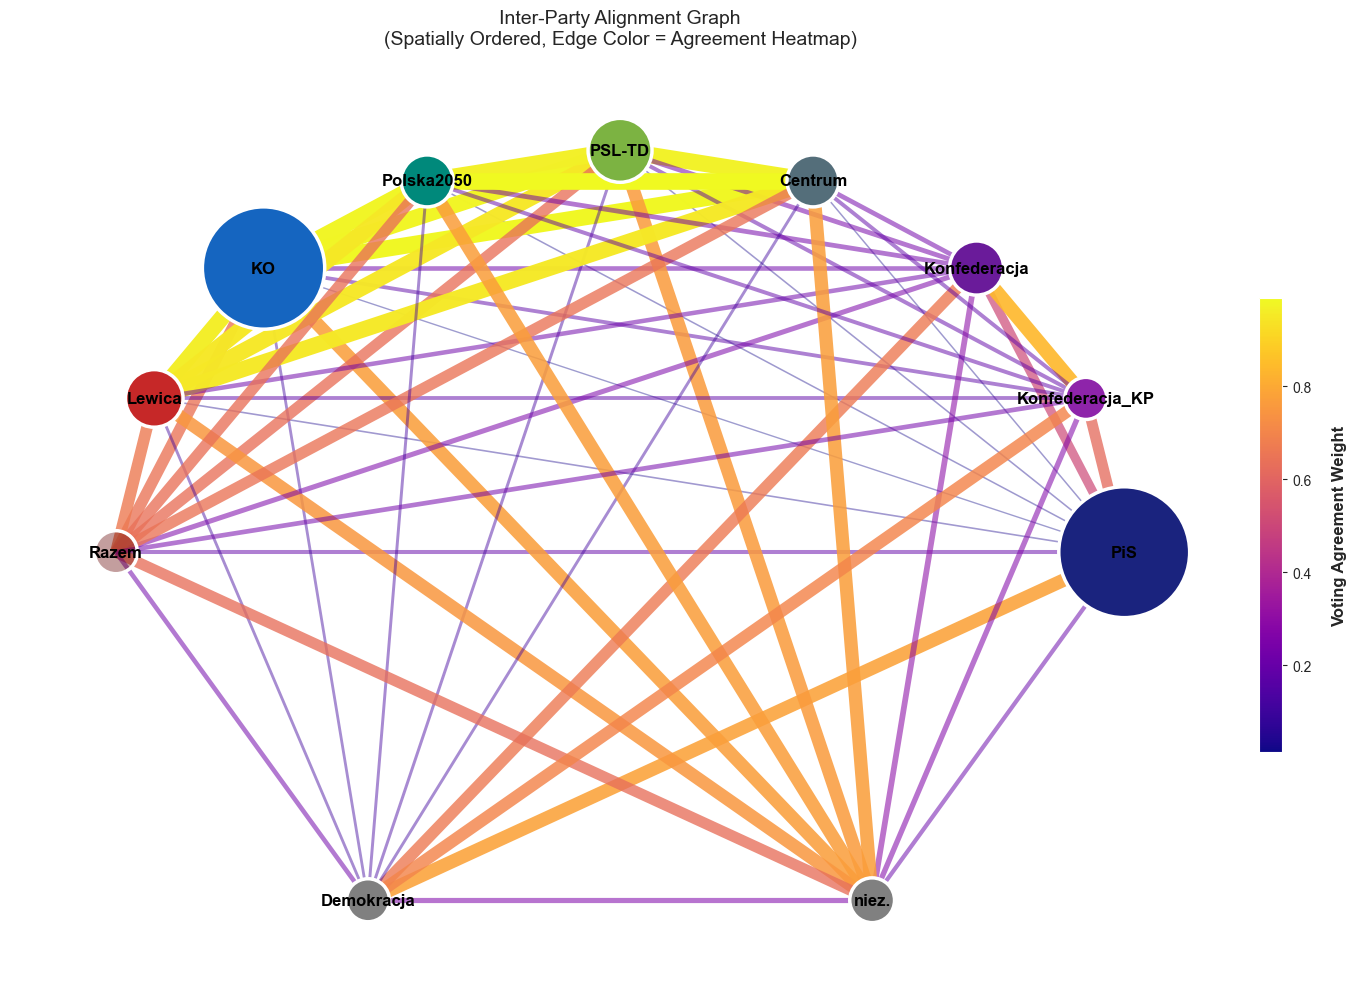

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ==========================================
# 1-6. DATA PREPARATION (Unchanged)
# ==========================================
mp_to_club = df_members.drop_duplicates(subset=["MP"]).set_index("MP")["club"].to_dict()

party_stats = edge_stats.copy()
party_stats["club_i"] = party_stats["MP_i"].map(mp_to_club)
party_stats["club_j"] = party_stats["MP_j"].map(mp_to_club)
party_stats = party_stats.dropna(subset=["club_i", "club_j"])

# Remove Polska2050-TD
party_stats = party_stats[
    (party_stats["club_i"] != "Polska2050-TD") &
    (party_stats["club_j"] != "Polska2050-TD")
]

party_stats["club_1"] = np.where(party_stats["club_i"] < party_stats["club_j"], party_stats["club_i"], party_stats["club_j"])
party_stats["club_2"] = np.where(party_stats["club_i"] >= party_stats["club_j"], party_stats["club_i"], party_stats["club_j"])

inter_party_stats = party_stats[party_stats["club_1"] != party_stats["club_2"]]

party_edges = inter_party_stats.groupby(["club_1", "club_2"], as_index=False).agg(
    score=("score", "sum"),
    denom=("denom", "sum")
)
party_edges["weight"] = party_edges["score"] / party_edges["denom"]

party_sizes = df_members["club"].value_counts().to_dict()
party_sizes.pop("Polska2050-TD", None)

P = nx.Graph()
for club, size in party_sizes.items():
    P.add_node(club, size=size, club=club)

for row in party_edges.itertuples(index=False):
    P.add_edge(row.club_1, row.club_2, weight=row.weight)

# ==========================================
# 7. VISUALIZATION (Updated with Heatmap Colors)
# ==========================================
plt.figure(figsize=(15, 10))

try:
    from utils.config import CLUBS_ORDERED, DEFAULT_CLUB_COLORS
except ImportError:
    CLUBS_ORDERED = []
    DEFAULT_CLUB_COLORS = {}

known_clubs = [c for c in CLUBS_ORDERED if c in P.nodes]
unknown_clubs = sorted([c for c in P.nodes if c not in known_clubs])

pos_p = {}
for i, club in enumerate(known_clubs):
    denom = max(len(known_clubs) - 1, 1)
    angle = np.pi - i * (np.pi / denom)
    pos_p[club] = (np.cos(angle), np.sin(angle))

for i, club in enumerate(unknown_clubs):
    angle = np.pi + (i + 1) * np.pi / (len(unknown_clubs) + 1)
    pos_p[club] = (np.cos(angle), np.sin(angle))

nodes = P.nodes()
edges = P.edges(data=True)

# Node Sizes & Colors
node_sizes = [800 + (P.nodes[n].get('size', 1) * 40) for n in nodes]

if DEFAULT_CLUB_COLORS:
    node_colors = [DEFAULT_CLUB_COLORS.get(n, "#808080") for n in nodes]
else:
    color_palette = sns.color_palette("tab20", len(nodes))
    club_colors_local = dict(zip(nodes, color_palette))
    node_colors = [club_colors_local.get(n, "#808080") for n in nodes]


# --- NEW: Edge Heatmap Configuration ---
# 'plasma' is a great sequential map (dark purple -> bright yellow).
# You can also try 'viridis', 'magma', or 'coolwarm'
edge_cmap = plt.cm.plasma

weights = [d["weight"] for _, _, d in edges]

if weights:
    min_w, max_w = min(weights), max(weights)
    norm_weights = [(w - min_w) / (max_w - min_w + 1e-5) for w in weights]

    # Generate widths, alphas, and now COLORS based on the normalized weight
    edge_widths = [1.0 + (11.0 * nw) for nw in norm_weights]

    # We can keep alpha slightly higher now so the colors are visible
    edge_alphas = [0.4 + (0.6 * nw) for nw in norm_weights]

    # Map the 0-1 values to actual RGB colors from the colormap
    edge_colors = [edge_cmap(nw) for nw in norm_weights]
else:
    edge_widths = [2.0] * len(edges)
    edge_alphas = [0.5] * len(edges)
    edge_colors = ["dimgray"] * len(edges)
    min_w, max_w = 0, 1

# Draw edges sequentially
for i, (u, v, d) in enumerate(edges):
    nx.draw_networkx_edges(
        P, pos_p,
        edgelist=[(u, v)],
        width=edge_widths[i],
        alpha=edge_alphas[i],
        edge_color=[edge_colors[i]], # Must be passed as a list
    )

# Draw Nodes
nx.draw_networkx_nodes(
    P, pos_p,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="white",
    linewidths=2.5,
)

# Draw Labels
pos_labels = {k: (v[0], v[1]) for k, v in pos_p.items()}
nx.draw_networkx_labels(
    P, pos_labels,
    font_size=12,
    font_weight="bold",
    font_color="black",
)

# --- NEW: Add the Colorbar Legend ---
# We create a dummy Mappable object just to draw the colorbar
sm = plt.cm.ScalarMappable(cmap=edge_cmap, norm=mcolors.Normalize(vmin=min_w, vmax=max_w))
sm.set_array([])

# Add the colorbar to the plot
cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.5, pad=0.02, aspect=20)
cbar.set_label("Voting Agreement Weight", fontsize=12, fontweight='bold', labelpad=15)

# Adjust axes limits
ax = plt.gca()

plt.title("Inter-Party Alignment Graph\n(Spatially Ordered, Edge Color = Agreement Heatmap)", fontsize=14, pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()